In [2]:
import numpy as np
import pandas as pd

In [3]:
df=pd.read_csv("mental_health_survey_dataset_300k.csv")
df=df.sample(10000,random_state=10)
df.head()

,participant_id,age,gender,country,occupation,work_hours_per_week,screen_time_hours,sleep_hours,sleep_quality,exercise_frequency,stress_score,anxiety_score,depression_score,social_support,therapy_history,family_history_mental_illness,academic_or_job_pressure,financial_stress_score,mental_health_risk,survey_date
53288,f19bec07-5025-4b7a-ad49-c561e826dc2e,20,Non-binary,Bangladesh,Software Engineer,66,2.5,8.4,Excellent,Sometimes,7,2,4,Moderate,No,No,7.0,2.0,Moderate,2026-01-09
130791,11cc68fb-3c6e-4e94-8ade-7547809f15a1,48,Female,Pakistan,Researcher,76,8.4,5.0,Poor,Regularly,3,2,9,Strong,Yes,Yes,7.0,3.0,High,2025-01-24
1969,de9f1aa3-ddbf-4f27-99a3-e7cede48213e,37,Male,USA,Data Scientist,32,6.2,9.9,Average,Never,6,3,3,Weak,Yes,No,5.0,6.0,Moderate,2025-11-04
69654,a7d655dc-5d75-492c-9846-1ae6c6a346cf,22,Prefer not to say,Bangladesh,Teacher,13,5.2,4.6,Poor,Rarely,9,6,4,Weak,Yes,No,5.0,3.0,High,2024-09-13
126885,a699071d-8fed-4931-85bd-c7cd0d7276a1,59,Prefer not to say,UAE,Researcher,20,6.9,7.1,Average,Rarely,2,10,10,Moderate,Yes,No,5.0,9.0,High,2024-11-30


In [4]:
df.shape

(10000, 20)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 53288 to 93892
Data columns (total 20 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   participant_id                 10000 non-null  object 
 1   age                            10000 non-null  int64  
 2   gender                         10000 non-null  object 
 3   country                        10000 non-null  object 
 4   occupation                     10000 non-null  object 
 5   work_hours_per_week            10000 non-null  int64  
 6   screen_time_hours              10000 non-null  float64
 7   sleep_hours                    10000 non-null  float64
 8   sleep_quality                  10000 non-null  object 
 9   exercise_frequency             10000 non-null  object 
 10  stress_score                   10000 non-null  int64  
 11  anxiety_score                  10000 non-null  int64  
 12  depression_score               10000 non-null  

In [6]:
print(df.duplicated().sum())

0


In [7]:
df.isnull().sum()

,0
participant_id,0
age,0
gender,0
country,0
occupation,0
work_hours_per_week,0
screen_time_hours,0
sleep_hours,0
sleep_quality,0
exercise_frequency,0


In [8]:
df.describe()

,age,work_hours_per_week,screen_time_hours,sleep_hours,stress_score,anxiety_score,depression_score,academic_or_job_pressure,financial_stress_score
count,10000.000000,10000.000000,10000.00000,10000.00000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000
mean,38.822500,45.041800,7.42720,6.54129,5.474000,5.501600,5.493300,5.52130,5.534800
std,12.404184,20.529515,3.73939,2.02683,2.842804,2.855663,2.847379,2.85737,2.879899
min,18.000000,10.000000,1.00000,3.00000,1.000000,1.000000,1.000000,1.00000,1.000000
25%,28.000000,27.000000,4.20000,4.80000,3.000000,3.000000,3.000000,3.00000,3.000000
50%,39.000000,45.000000,7.40000,6.60000,6.000000,5.000000,5.000000,6.00000,6.000000
75%,50.000000,63.000000,10.60000,8.30000,8.000000,8.000000,8.000000,8.00000,8.000000
max,60.000000,80.000000,14.00000,10.00000,10.000000,10.000000,10.000000,10.00000,10.000000


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

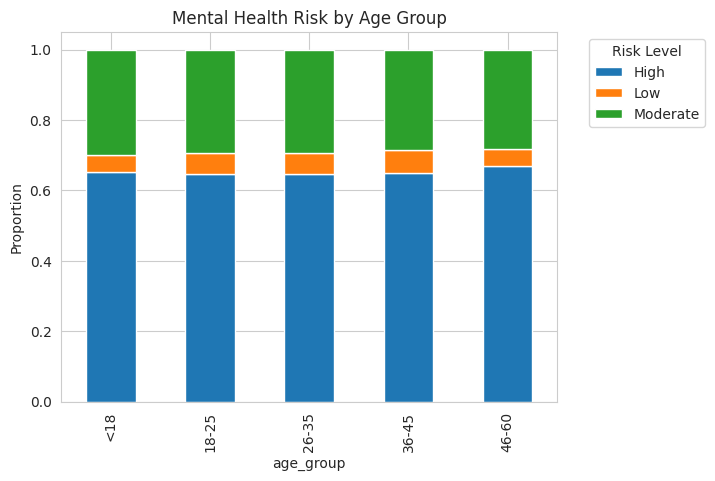

In [12]:
df['age_group'] = pd.cut(df['age'], bins=[0,18,25,35,45,60,100],labels=['<18','18-25','26-35','36-45','46-60','60+'])

risk_by_age = pd.crosstab(df['age_group'], df['mental_health_risk'], normalize='index')
risk_by_age.plot(kind='bar', stacked=True)
plt.title("Mental Health Risk by Age Group")
plt.ylabel("Proportion")
plt.legend(title="Risk Level", bbox_to_anchor=(1.05,1))
plt.show()

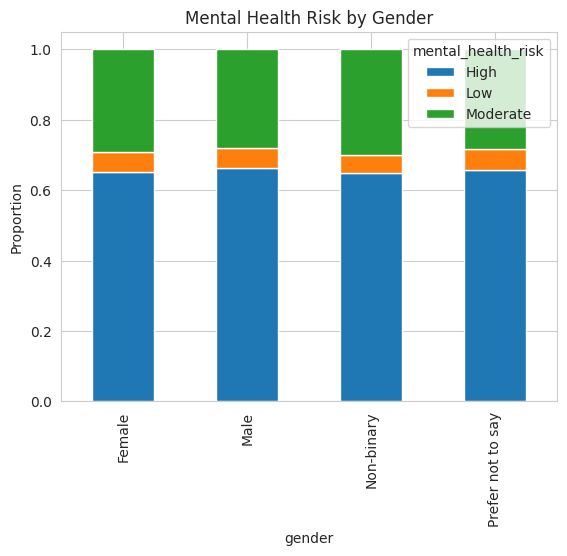

In [13]:
risk_by_gender = pd.crosstab(df['gender'], df['mental_health_risk'], normalize='index')
risk_by_gender.plot(kind='bar', stacked=True)
plt.title("Mental Health Risk by Gender")
plt.ylabel("Proportion")
plt.show()

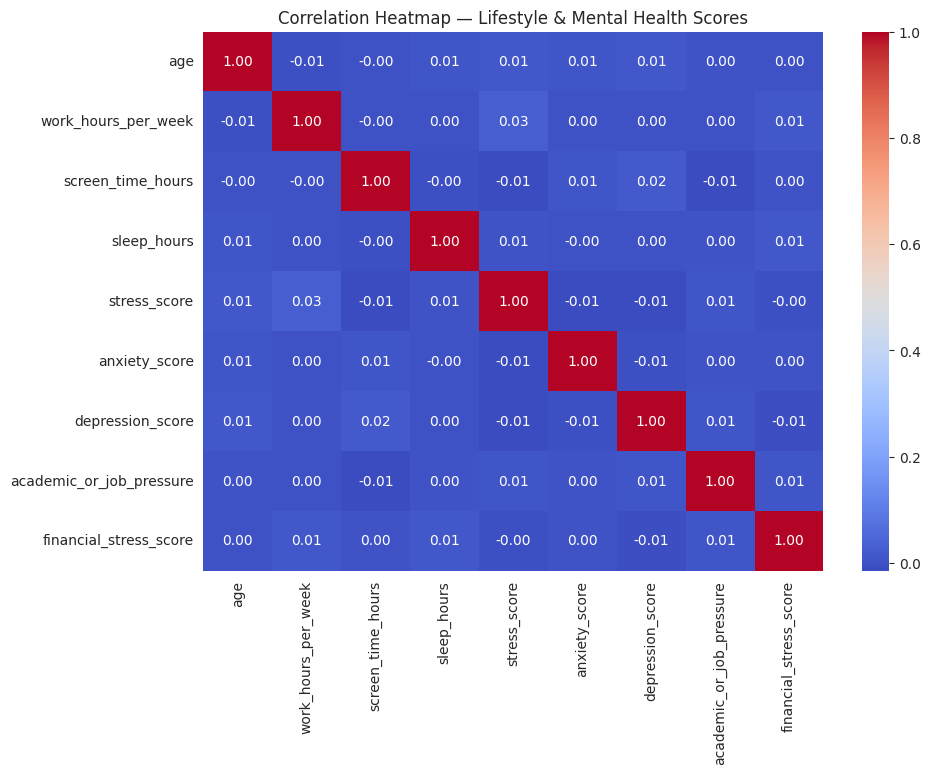

In [14]:
num_cols = ['age','work_hours_per_week','screen_time_hours','sleep_hours','stress_score','anxiety_score','depression_score','academic_or_job_pressure','financial_stress_score']
plt.figure(figsize=(10,7))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap — Lifestyle & Mental Health Scores")
plt.show()

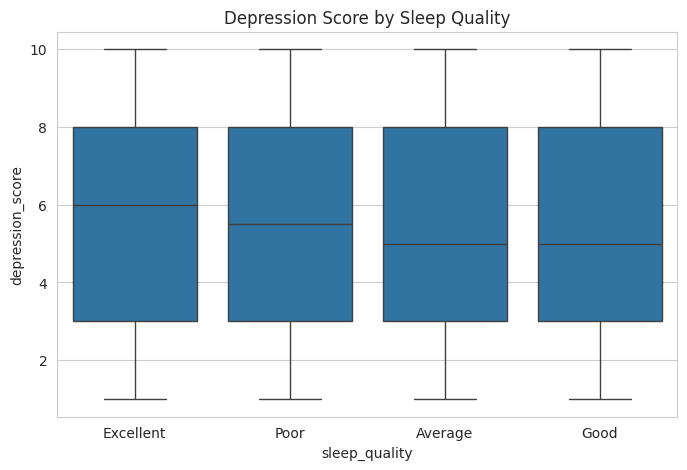

In [15]:
plt.figure(figsize=(8,5))
sns.boxplot(x='sleep_quality', y='depression_score', data=df)
plt.title("Depression Score by Sleep Quality")
plt.show()

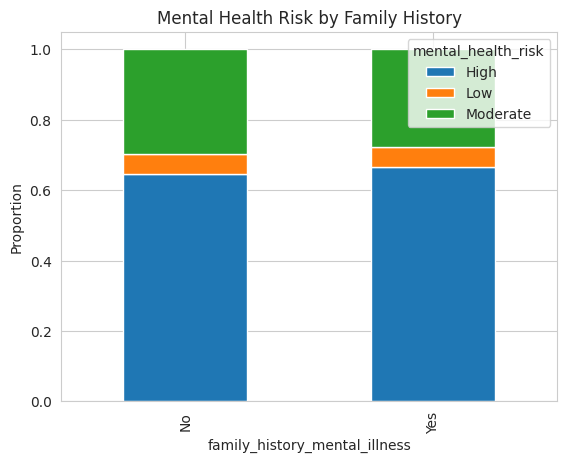

In [16]:
risk_by_history = pd.crosstab(df['family_history_mental_illness'], df['mental_health_risk'], normalize='index')
risk_by_history.plot(kind='bar', stacked=True)
plt.title("Mental Health Risk by Family History")
plt.ylabel("Proportion")
plt.show()

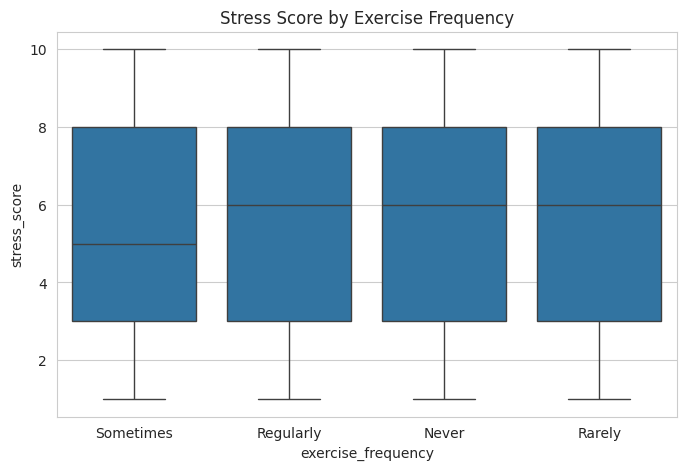

In [17]:
plt.figure(figsize=(8,5))
sns.boxplot(x='exercise_frequency', y='stress_score', data=df)
plt.title("Stress Score by Exercise Frequency")
plt.show()

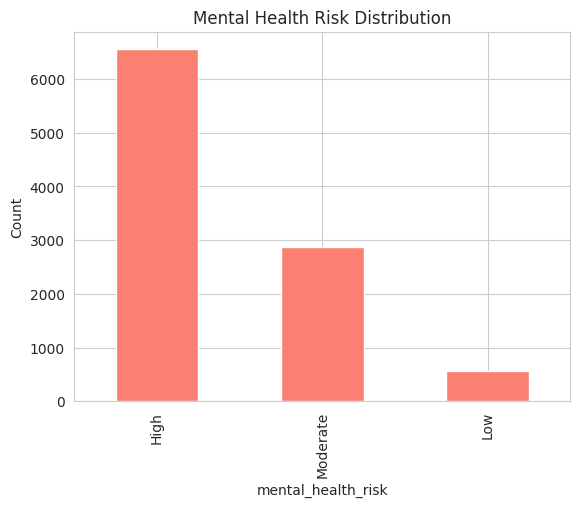

In [18]:
df['mental_health_risk'].value_counts().plot(kind='bar', color='salmon')
plt.title("Mental Health Risk Distribution")
plt.ylabel("Count")
plt.show()

In [19]:
df.to_csv("mental_health_cleaned.csv",index=False)